In [1]:
import os
import glob
import sys

import itertools

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pytorch_lightning as pl

from IPython.display import clear_output

In [2]:
# Load all models
from optimus5 import Optimus5PrimeOriginal
from optimus5_25 import Optimus5Prime25
from mttrans import RL_gru
from framepool import FramePool
from dream_wrappers import DreamRNNFacade, DreamAttnFacade

In [3]:
sys.path.append("../../predictor/model/")
import utrdata_cl as utrdata
from pl_regressor import RNARegressor
from legnet_classifier import LegNetClassifier

In [4]:
utr_type = "utr3"
seqsize = 50 if utr_type == "utr5" else 240

## Loading data

In [5]:
PATH_FROM = f"../../predictor/regression_multiple/{utr_type.upper()}_zscores_replicateagg.csv"
df = pd.read_csv(PATH_FROM)

In [6]:
num_classes = df["cell_type"].unique().shape[0]
num_classes

6

In [7]:
splits = dict(tuple(df.groupby('fold')))
for split_df in splits.values():
    split_df.reset_index(drop=True, inplace=True)
splits["test"].head()

,seq,cell_type,fold,1,2,3,4,mass_center,mass_center_mean,diff,zscore,mass_center_std
0,AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...,c1,test,10.930684,7.519106,9.592497,8.605105,2.433101,2.613522,-0.180421,-0.975516,0.184949
1,AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...,c13,test,13.668966,13.073336,11.705055,11.700622,2.427481,2.613522,-0.186041,-1.005901,0.184949
2,AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...,c17,test,12.064452,5.648295,6.148830,24.796787,2.897645,2.613522,0.284123,1.536220,0.184949
3,AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...,c2,test,12.491993,9.447546,17.713293,12.928093,2.591041,2.613522,-0.022481,-0.121553,0.184949
4,AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...,c4,test,6.787326,2.369534,4.600547,7.061687,2.573348,2.613522,-0.040174,-0.217215,0.184949


In [8]:
batch_size = 128

In [9]:
num_workers = 32

In [10]:
test_set = utrdata.UTRData(
    df=splits["test"],
    predict_cols=["mass_center"],
    construct_type=utr_type,
    features=("sequence", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
dl_test = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

parade_test_set = utrdata.UTRData(
    df=splits["test"],
    construct_type=utr_type,
    features=("sequence", "positional", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
parade_dl_test = DataLoader(
    parade_test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

### Loading models

In [11]:
legnet_checkpoint = glob.glob(f"../../predictor/regression_multiple/saved_models/model-{utr_type}*.ckpt")[0]
model_checkpoints = {os.path.basename(os.path.dirname(path)): path for path in glob.glob(f"./saved_models/{utr_type}/*/*.ckpt")}
model_checkpoints

{'DreamAttnFacade': './saved_models/utr3/DreamAttnFacade/epoch=3-step=17052.ckpt',
 'DreamRNNFacade': './saved_models/utr3/DreamRNNFacade/epoch=27-step=119364.ckpt',
 'Optimus5PrimeOriginal': './saved_models/utr3/Optimus5PrimeOriginal/epoch=9-step=10650.ckpt',
 'FramePool': './saved_models/utr3/FramePool/epoch=7-step=8520.ckpt',
 'Optimus5Prime25': './saved_models/utr3/Optimus5Prime25/epoch=9-step=10650.ckpt',
 'RL_gru': './saved_models/utr3/RL_gru/epoch=99-step=426300.ckpt'}

In [12]:
models = dict()
for model_name, ckpt_path in model_checkpoints.items():
    ckpt = torch.load(ckpt_path)
    loaded_model = RNARegressor(**ckpt["hyper_parameters"])
    loaded_model.load_state_dict(ckpt["state_dict"])
    models[model_name] = loaded_model
legnet_ckpt = torch.load(legnet_checkpoint)
legnet_model = RNARegressor(**legnet_ckpt["hyper_parameters"])
legnet_model.load_state_dict(legnet_ckpt["state_dict"])

<All keys matched successfully>

In [13]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    logger=False,
    accelerator="gpu",
    devices=[0],
    deterministic=True,
    num_sanity_val_steps=0,
)
result_df = splits["test"][["seq", "cell_type", "mass_center"]].copy()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [14]:
for model_name, model_instance in models.items():
    print(model_name)
    prediction = trainer.predict(model=model_instance, dataloaders=dl_test)
    test_pred, test_real = zip(*prediction)
    test_pred = torch.concat(test_pred).numpy()
    # test_real = torch.concat(test_real).numpy()
    result_df[model_name] = test_pred[:, 0]

DreamAttnFacade


You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


DreamRNNFacade


...

Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


RL_gru


Traceback (most recent call last):
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/shutil.py", line 738, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/shutil.py", line 736, in rmtree
    os.rmdir(path, dir_fd=dir_fd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-2z0sn7r1'


Predicting: 0it [00:00, ?it/s]

In [15]:
print("LegNetClassifier")
prediction = trainer.predict(model=legnet_model, dataloaders=parade_dl_test)
test_pred, test_real = zip(*prediction)
test_pred = torch.concat(test_pred).numpy()
# test_real = torch.concat(test_real).numpy()
result_df["LegNetClassifier"] = test_pred[:, 1]
result_df["LegNetClassifier_delta"] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LegNetClassifier


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Traceback (most recent call last):
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/shutil.py", line 738, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/shutil.py", line 736, in rmtree
    os.rmdir(path, dir_fd=dir_fd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-j3f2oyn0'


Predicting: 0it [00:00, ?it/s]

In [16]:
result_df_r = pd.concat({"pred_mass_center": result_df.drop(["seq", "cell_type", "mass_center"], axis=1)}, axis=1)
for i, col in enumerate(["seq", "cell_type", "mass_center"]):
    result_df_r.insert(i, col, result_df[col])
result_df_r

seq cell_type  \
                                                                     
0      AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...        c1   
1      AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...       c13   
2      AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...       c17   
3      AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...        c2   
4      AAAAAAAGAGAGACCTGTCATTAGAAGCAACCAGGTTCTCCTGATA...        c4   
...                                                  ...       ...   
17047  TTTTTTTTTTTTTTTCCGTCTCCCCAAAGCTTTATCTGTCTTGACT...       c13   
17048  TTTTTTTTTTTTTTTCCGTCTCCCCAAAGCTTTATCTGTCTTGACT...       c17   
17049  TTTTTTTTTTTTTTTCCGTCTCCCCAAAGCTTTATCTGTCTTGACT...        c2   
17050  TTTTTTTTTTTTTTTCCGTCTCCCCAAAGCTTTATCTGTCTTGACT...        c4   
17051  TTTTTTTTTTTTTTTCCGTCTCCCCAAAGCTTTATCTGTCTTGACT...        c6   

      mass_center pred_mass_center                                       \
                   DreamAttnFacade DreamRNNFacade Optimus5PrimeOriginal   
0        2.433101         2.633721       2.513785              2.614939   
1        2.427481         2.660315       2.559929              2.663833   
2        2.897645         2.903219       2.709808              2.749637   
3        2.591041         2.702907       2.525529              2.652398   
4        2.573348         2.807939       2.673169              2.706797   
...           ...              ...            ...                   ...   
17047    2.722813         2.708853       2.644869              2.624736   
17048    2.787094         2.892645       2.822601              2.832896   
17049    2.520863         2.867785       2.698038              2.668008   
17050    2.891843         2.828382       2.873616              2.789248   
17051    2.881207         2.838281       2.724618              2.711521   

                                                            \
      FramePool Optimus5Prime25    RL_gru LegNetClassifier   
0      2.520650        2.443676  2.528197         2.560895   
1      2.514099        2.476919  2.648402         2.663368   
2      2.597567        2.618045  2.787890         2.893668   
3      2.481857        2.491630  2.635713         2.682586   
4      2.615949        2.602049  2.702548         2.829537   
...         ...             ...       ...              ...   
17047  2.503232        2.551581  2.630346         2.534672   
17048  2.542366        2.572171  2.765668         2.605438   
17049  2.565660        2.601887  2.740549         2.626874   
17050  2.512135        2.565281  2.729047         2.617524   
17051  2.502201        2.596099  2.712759         2.590229   

                              
      LegNetClassifier_delta  
0                  -0.162178  
1                  -0.073500  
2                   0.112839  
3                  -0.040800  
4                   0.010652  
...                      ...  
17047              -0.084407  
17048              -0.022081  
17049               0.004859  
17050              -0.033582  
17051              -0.048381  

[17052 rows x 11 columns]

In [17]:
result_df_r.to_parquet(f"benchmark_preds_{utr_type}.parquet")

In [18]:
correlations = result_df.groupby("cell_type")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].corr()["mass_center"].unstack(0).drop("mass_center", axis=0)
correlations["mean"] = result_df.groupby("seq")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].mean().corr()["mass_center"].drop("mass_center")
correlations

cell_type,c1,c13,c17,c2,c4,c6,mean
DreamAttnFacade,0.726348,0.612365,0.658440,0.714987,0.588607,0.674365,0.744557
DreamRNNFacade,0.760843,0.638966,0.700693,0.733020,0.631982,0.705308,0.773123
Optimus5PrimeOriginal,0.693070,0.591213,0.636713,0.681983,0.556513,0.640560,0.715252
FramePool,0.698959,0.557188,0.627411,0.668813,0.556859,0.625557,0.710540
Optimus5Prime25,0.734939,0.624001,0.679125,0.728721,0.616759,0.699554,0.764170
RL_gru,0.725352,0.578908,0.624039,0.698280,0.562568,0.642997,0.720291
LegNetClassifier,0.737771,0.654717,0.719844,0.750149,0.650344,0.728190,0.792601


<Axes: ylabel='cell_type'>

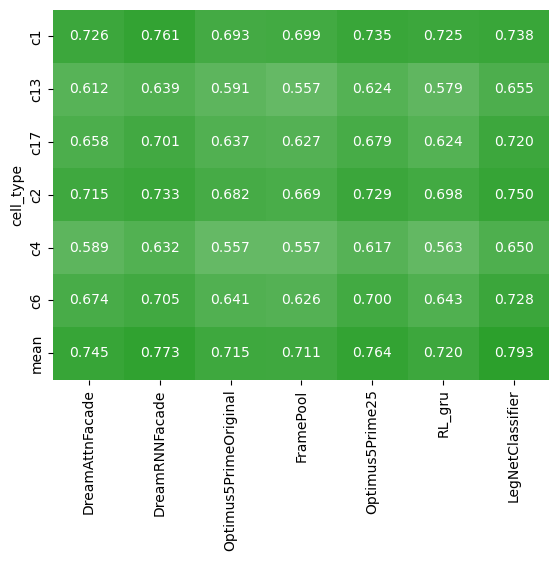

In [19]:
sns.heatmap(correlations.T, cmap=sns.color_palette("light:C2", n_colors=1000, as_cmap=True), vmin=0,
            annot=True, fmt=".3f", cbar=False)

In [20]:
correlations.mean(axis=1).sort_values(ascending=False)

LegNetClassifier         0.719088
DreamRNNFacade           0.706276
Optimus5Prime25          0.692467
DreamAttnFacade          0.674238
RL_gru                   0.650348
Optimus5PrimeOriginal    0.645043
FramePool                0.635047
dtype: float64

In [21]:
list(zip(correlations.columns, correlations.index[correlations.values.argmax(axis=0)]))

[('c1', 'DreamRNNFacade'),
 ('c13', 'LegNetClassifier'),
 ('c17', 'LegNetClassifier'),
 ('c2', 'LegNetClassifier'),
 ('c4', 'LegNetClassifier'),
 ('c6', 'LegNetClassifier'),
 ('mean', 'LegNetClassifier')]

---